In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
from neural_capm.evaluation.backtest import chronological_split
from neural_capm.models.sequence_prep import create_sequences

reliance_matrix = pd.read_csv("../data/processed/RELIANCE_NS_feature_matrix.csv", index_col=0, parse_dates=True)
print(reliance_matrix.shape)
reliance_matrix.head()

(2367, 5)


,india_cpi,india_10y_yield,momentum,volatility,beta_target
2015-05-21,97.92796,7.85218,0.032166,0.016950,1.036663
2015-05-22,97.92796,7.85218,0.043541,0.016965,1.038104
2015-05-25,97.92796,7.85218,0.030572,0.017198,1.037551
2015-05-26,97.92796,7.85218,0.023358,0.017390,1.040155
2015-05-27,97.92796,7.85218,0.036123,0.017127,1.040078


In [2]:
train_df, val_df, test_df = chronological_split(reliance_matrix, train_end="2021-12-31", val_end="2022-12-31")

print("Train:", train_df.shape, train_df.index.min(), "to", train_df.index.max())
print("Val:  ", val_df.shape, val_df.index.min(), "to", val_df.index.max())
print("Test: ", test_df.shape, test_df.index.min(), "to", test_df.index.max())

Train: (1629, 5) 2015-05-21 00:00:00 to 2021-12-31 00:00:00
Val:   (248, 5) 2022-01-03 00:00:00 to 2022-12-30 00:00:00
Test:  (490, 5) 2023-01-02 00:00:00 to 2024-12-30 00:00:00


In [3]:
feature_cols = ["india_cpi", "india_10y_yield", "momentum", "volatility"]

X_train, y_train, dates_train = create_sequences(train_df[feature_cols], train_df["beta_target"], sequence_length=30)
X_val, y_val, dates_val = create_sequences(val_df[feature_cols], val_df["beta_target"], sequence_length=30)
X_test, y_test, dates_test = create_sequences(test_df[feature_cols], test_df["beta_target"], sequence_length=30)

print("Train sequences:", X_train.shape, y_train.shape)
print("Val sequences:  ", X_val.shape, y_val.shape)
print("Test sequences: ", X_test.shape, y_test.shape)

Train sequences: (1599, 30, 4) (1599,)
Val sequences:   (218, 30, 4) (218,)
Test sequences:  (460, 30, 4) (460,)


In [4]:
import torch
import torch.nn as nn
from neural_capm.models.lstm_beta import LSTMBetaPredictor
from neural_capm.models.sequence_prep import FeatureScaler, create_sequences

# 1. Fit scaler on train features ONLY, apply everywhere
scaler = FeatureScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

# 2. Re-sequence using the SCALED features (targets stay unscaled)
X_train, y_train, dates_train = create_sequences(train_scaled, train_df["beta_target"], sequence_length=30)
X_val, y_val, dates_val = create_sequences(val_scaled, val_df["beta_target"], sequence_length=30)
X_test, y_test, dates_test = create_sequences(test_scaled, test_df["beta_target"], sequence_length=30)

# 3. Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)

torch.Size([1599, 30, 4]) torch.Size([1599])


In [5]:
import torch
import torch.nn as nn
import numpy as np

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

model = LSTMBetaPredictor(n_features=4, hidden_size=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 200
batch_size = 64
patience = 20  # stop if val loss doesn't improve for this many epochs

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

train_losses = []
val_losses = []

n_train = X_train_t.shape[0]

for epoch in range(n_epochs):
    model.train()
    permutation = torch.randperm(n_train)   # shuffle WITHIN training set only -- fine, since
                                              # this doesn't cross the train/val/test boundary
    epoch_train_loss = 0.0

    for i in range(0, n_train, batch_size):
        indices = permutation[i:i + batch_size]
        X_batch = X_train_t[indices]
        y_batch = y_train_t[indices]

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() * len(indices)

    epoch_train_loss /= n_train
    train_losses.append(epoch_train_loss)

    # validation pass -- no gradient updates, just measuring performance
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val_t)
        val_loss = criterion(val_predictions, y_val_t).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_state = model.state_dict()
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0 or epochs_without_improvement == 0:
        print(f"Epoch {epoch:3d} | train_loss: {epoch_train_loss:.6f} | val_loss: {val_loss:.6f}")

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
        break

# restore the BEST model seen during training, not necessarily the last one
model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.6f}")

Epoch   0 | train_loss: 1.046276 | val_loss: 0.751153
Epoch   1 | train_loss: 0.229438 | val_loss: 0.010902
Epoch   2 | train_loss: 0.012514 | val_loss: 0.003509
Epoch   3 | train_loss: 0.003376 | val_loss: 0.000529
Epoch   7 | train_loss: 0.002797 | val_loss: 0.000439
Epoch  10 | train_loss: 0.002708 | val_loss: 0.000504
Epoch  20 | train_loss: 0.002324 | val_loss: 0.002862
Early stopping at epoch 27 (no improvement for 20 epochs)

Best validation loss: 0.000439


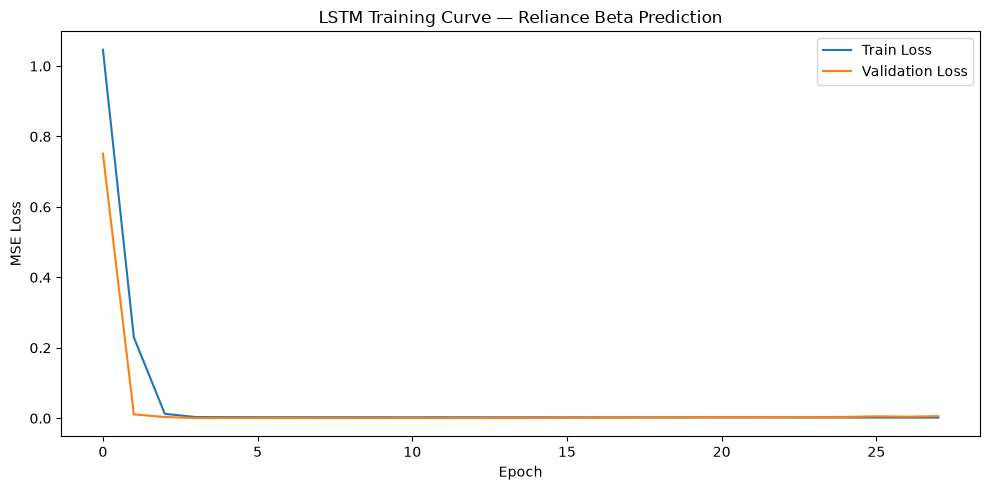

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training Curve — Reliance Beta Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/lstm_training_curve_reliance.png", dpi=150)
plt.show()

In [7]:
# Naive baseline 1: predict the training-set mean beta for every validation point
naive_mean_pred = np.full_like(y_val, y_train.mean())
naive_mean_mse = np.mean((y_val - naive_mean_pred) ** 2)

# Naive baseline 2: predict "tomorrow's beta = today's beta" (last known value carried forward)
# this uses the last beta value INSIDE each sequence's window as the prediction
naive_persistence_pred = X_val[:, -1, :].shape  # placeholder check first
print(feature_cols)  # confirm beta_target is NOT one of the input features (it shouldn't be)

['india_cpi', 'india_10y_yield', 'momentum', 'volatility']


In [8]:
# Naive baseline 1: predict training-set mean beta for every validation point
naive_mean_pred = np.full_like(y_val, y_train.mean())
naive_mean_mse = np.mean((y_val - naive_mean_pred) ** 2)

# Naive baseline 2: "persistence" -- predict tomorrow's beta = the beta from
# exactly one day before the target date (pulled from val_df directly,
# using the date alignment from create_sequences)
val_beta_series = val_df["beta_target"]
persistence_pred = val_beta_series.shift(1).loc[dates_val]
persistence_actual = val_beta_series.loc[dates_val]
naive_persistence_mse = np.mean((persistence_actual.values - persistence_pred.values) ** 2)

print(f"Naive mean-prediction MSE:        {naive_mean_mse:.6f}")
print(f"Naive persistence (t-1) MSE:      {naive_persistence_mse:.6f}")
print(f"LSTM best validation MSE:         {best_val_loss:.6f}")

Naive mean-prediction MSE:        0.000054
Naive persistence (t-1) MSE:      0.000007
LSTM best validation MSE:         0.000439
